# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;warnings.filterwarnings("ignore")
import netCDF4 as nc4;        import pandas as pd
import pathlib as pl;         import os
import numpy as np;           import xarray as xr
import geopandas as gpd;
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from functools import partial
from scipy.signal import find_peaks
from scipy.sparse import coo_matrix
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pymannkendall as mk

In [2]:

def compute_keep_idx(sample_path, min_depth, max_depth):
    """
    Return indices of nodes whose depth is between min_depth and max_depth,
    excluding fill‐values.
    """
    ds0   = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    depth = ds0.depth.values
    fv    = ds0.depth.encoding.get("_FillValue", None)
    mask  = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)                  # drop missing
    mask &= (depth >= min_depth)             # deeper than shore
    mask &= (depth <= max_depth)             # shallower than cutoff
    keep_idx = np.where(mask)[0]
    ds0.close()
    return keep_idx


def open_zeta_dataset(root_path, years, keep_idx,
                      chunks={"time":1000, "node":20000}):
    """
    Read each year’s CF‑ified file (no chunks at open), preprocess it,
    then chunk and concatenate along time.
    """
    ds_list = []
    for year in years:
        path = pl.Path(root_path) / str(year) / "fort.63.cf.nc"
        # 1) Open without chunks
        ds = xr.open_dataset(path,
                             engine="netcdf4",
                             mask_and_scale=False)

        # 2) Preprocess (time mask, spin‑up drop, node slice)
        ds = preprocess(ds, year, keep_idx)

        # 3) Now apply chunking on the cleaned dataset
        ds = ds.chunk(chunks)

        ds_list.append(ds)

    # 4) Concatenate all years along time
    return xr.concat(ds_list, dim="time")

def build_adjacency(global_conn, keep_idx):
    """
    Filter the global connectivity to only triangles fully inside keep_idx,
    remap to local indices, and build a CSR adjacency matrix.
    """
    # 1) select triangles whose 3 nodes are all in keep_idx
    mask_tri = np.all(np.isin(global_conn, keep_idx), axis=1)
    tri_filt = global_conn[mask_tri]

    # 2) build a map from global -> local
    local_map = {g: i for i, g in enumerate(keep_idx)}
    # 3) remap
    remap = np.vectorize(local_map.get)(tri_filt)

    # 4) assemble edges
    row = np.hstack([remap[:,0], remap[:,1],
                     remap[:,1], remap[:,2],
                     remap[:,2], remap[:,0]])
    col = np.hstack([remap[:,1], remap[:,0],
                     remap[:,2], remap[:,1],
                     remap[:,0], remap[:,2]])
    data = np.ones_like(row, dtype=int)

    N = len(keep_idx)
    return sparse.coo_matrix((data, (row, col)), shape=(N, N)).tocsr()


def compute_keep_idx2(
    sample_path,
    min_depth,
    max_depth,
    bbox=None,
):
    """
    Return indices of nodes whose depth is between min_depth and max_depth,
    optionally also lying within a bounding box in x/y.

    Parameters
    ----------
    sample_path : str or Path
        Path to a CF‑ified fort.63 file.
    min_depth, max_depth : float
        Depth range (inclusive) in meters.
    bbox : tuple of floats (min_x, max_x, min_y, max_y), optional
        If given, further restrict to nodes with:
           min_x <= x <= max_x  AND  min_y <= y <= max_y.

    Returns
    -------
    keep_idx : np.ndarray of int
        Indices of the `node` dimension satisfying your criteria.
    """
    ds0 = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    
    # 1) depth mask
    depth = ds0.depth.values
    fv    = ds0.depth.encoding.get("_FillValue", None)
    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth)
    mask &= (depth <= max_depth)

    # 2) optional bbox mask
    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x = ds0.x.values
        y = ds0.y.values
        mask &= (x >= min_x) & (x <= max_x)
        mask &= (y >= min_y) & (y <= max_y)

    ds0.close()
    return np.where(mask)[0]

SPINUP_HRS  = 14*24
def preprocess(ds):
    # 1) decode raw time → pandas
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) drop anything outside that calendar year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    #ds = ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
    # 3) drop the spin‑up
    ds = ds.isel(time=mask)
    # 4) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    return ds


In [3]:
from dask.distributed import Client, LocalCluster
import math
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "10GB")

cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu
)
client = Client(cluster)
print(client)
SPINUP_DAYS= 14
DROP_START = SPINUP_DAYS * 24

<Client: 'tcp://127.0.0.1:42461' processes=45 threads=45, memory=419.10 GiB>


In [4]:
lat1, lat2 = 56.5, 74
lon1, lon2 = -168.5, -140

root = '/scratch/tmiesse/project/data4spatial'
YEARS = range(2020, 2025)
MIN_DEPTH = 0.25
MAX_DEPTH = 20
bbox = (lon1, lon2, lat1, lat2)
sample_path = f"{root}/2023/fort.63.cf.nc"
keep_idx = compute_keep_idx2(
    sample_path=sample_path,
    min_depth=MIN_DEPTH,
    max_depth=MAX_DEPTH,
    bbox=bbox
)
print(f"Keeping {len(keep_idx)}")

Keeping 438488


In [5]:
paths = [str(pl.Path(root)/str(y)/"fort.63.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess,
            combine="nested",
            concat_dim="time",
            chunks={'time':24},
            coords="minimal")

times  = ds_all.time.values      # length T
z = ds_all.zeta.values
x_all  = ds_all.x.values                          # (n_nodes,)
y_all  = ds_all.y.values                          # (n_nodes,)


2025-09-15 09:15:38,520 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.13 GiB -- Worker memory limit: 9.31 GiB


In [6]:
file = "/scratch/tmiesse/project/surge_events_declustered3.nc"
ds_events = xr.open_dataset(file)
times = pd.to_datetime(ds_events["time"].values)


# Count events per year
years = times.year
counts = pd.Series(years).value_counts().sort_index()

In [7]:
print(ds_events)

<xarray.Dataset> Size: 28kB
Dimensions:        (event: 355)
Coordinates:
  * event          (event) int32 1kB 0 1 2 3 4 5 6 ... 349 350 351 352 353 354
    time           (event) datetime64[ns] 3kB 1980-01-24T15:00:00 ... 2024-12...
Data variables:
    area95_km2     (event) float64 3kB ...
    nodes95_count  (event) int64 3kB ...
    core_lon       (event) float64 3kB ...
    core_lat       (event) float64 3kB ...
    peak_s3        (event) float64 3kB ...
    node_local     (event) int64 3kB ...
    node_global    (event) int64 3kB ...
    time_index     (event) int64 3kB ...
    year           (event) int16 710B ...
    month          (event) int8 355B ...
    day            (event) int8 355B ...
Attributes:
    description:          Declustered surge events: core location, 95% footpr...
    footprint_threshold:  95th percentile per node (support), anchored to 99....
    decluster_params:     W=72h, Jaccard_area>=0.20 OR core_distance<=300km (...


In [8]:
ds_events.core_lon

<xarray.DataArray 'core_lon' (event: 355)> Size: 3kB
[355 values with dtype=float64]
Coordinates:
  * event    (event) int32 1kB 0 1 2 3 4 5 6 7 ... 348 349 350 351 352 353 354
    time     (event) datetime64[ns] 3kB 1980-01-24T15:00:00 ... 2024-12-18T03...

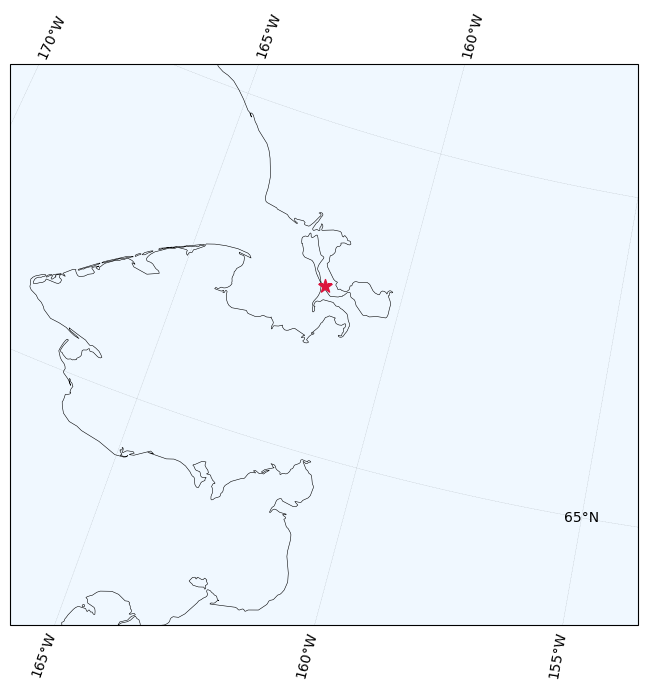

In [62]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Polygon
from pyproj import Geod
extent  = [-167, -155, 64., 68]  # [lon_min, lon_max, lat_min, lat_max]
proj    = ccrs.NorthPolarStereo(central_longitude=-145)


fig = plt.figure(figsize=(9,7))
ax  = plt.axes(projection=proj)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.coastlines(resolution="10m", linewidth=0.4, color="black", zorder=1)
ax.gridlines(
    xlocs=np.arange(-180, -100, 5),
    ylocs=np.arange(50, 90, 3),
    draw_labels=True, linewidth=0.2,
    color='black', alpha=0.3, linestyle='--'
)
t_all = pd.to_datetime(ds_events["time"].values)
mask  = t_all.year == 1990
#if not mask.any():
#    raise ValueError("No events in 1983")
idx = np.where(mask)[0]#[0][0])  # first event in 1983

# --- helpers ---
geod = Geod(ellps="WGS84")

def geodesic_circle(lon0, lat0, radius_km, n=180):
    """
    Return a shapely Polygon approximating a geodesic circle of given radius (km).
    Ensures all inputs to Geod.fwd have matching lengths.
    """
    if not np.isfinite(radius_km) or radius_km <= 0:
        return None
    lon0 = float(lon0)
    lat0 = float(lat0)
    az   = np.linspace(0.0, 360.0, n, endpoint=False, dtype=float)
    lonA = np.full(az.shape, lon0, dtype=float)
    latA = np.full(az.shape, lat0, dtype=float)
    dist = np.full(az.shape, radius_km * 1000.0, dtype=float)  # meters
    lons, lats, _ = geod.fwd(lonA, latA, az, dist)  # radians=False by default
    return Polygon(zip(lons, lats))
lon0,lat0,t0,A95,r_km,poly = [],[],[],[],[],[]

for i in idx:
    lon00 = float(ds_events["core_lon"].isel(event=i).values)
    lat00 = float(ds_events["core_lat"].isel(event=i).values)
    t00   = pd.to_datetime(ds_events["time"].isel(event=i).values)
    A950  = float(ds_events["area95_km2"].isel(event=i).values)
    r_km0 = np.sqrt(A950/np.pi) if np.isfinite(A950) and A950 > 0 else np.nan
    poly0 = geodesic_circle(lon00, lat00, r_km0) if np.isfinite(r_km0) else None
    lon0.append(lon00)
    lat0.append(lat00)
    t0.append(t00)
    A95.append(A950)
    r_km.append(r_km0)
    #if poly0 is not None:
    #    ax.add_geometries([poly0], ccrs.PlateCarree(),
    #                    facecolor="tab:blue", edgecolor="k", alpha=0.25, linewidth=0.6,
    #                    label="Equal-area (A95)")

# core marker
ax.scatter(lon0, lat0, marker="*", c="crimson", s=100,
        transform=ccrs.PlateCarree(), label="Event core")


#ax.scatter(x_all, y_all,s=0.1, color="black", alpha=0.5, transform=ccrs.PlateCarree())



plt.tight_layout()

plt.show()

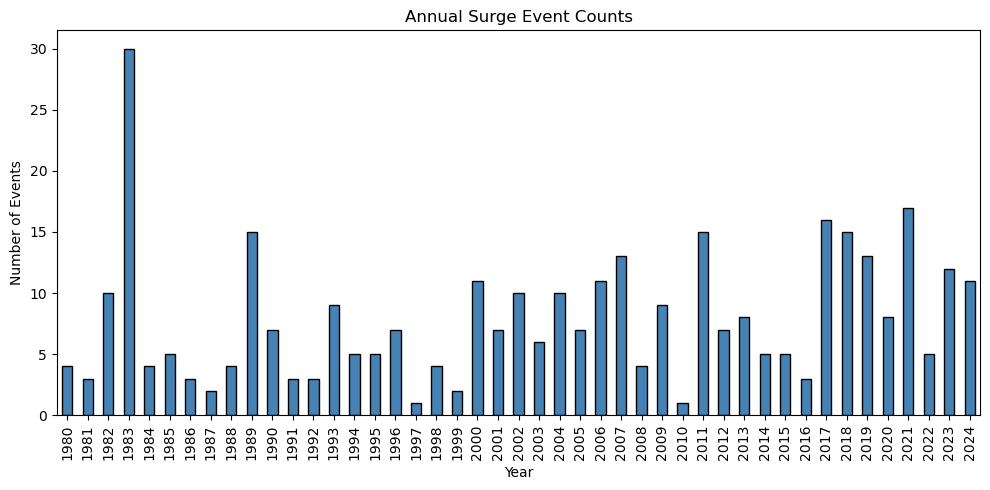

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")

ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.set_title("Annual Surge Event Counts")
plt.xticks(rotation=90)
plt.tight_layout()

#plt.savefig("/scratch/tmiesse/project/figures/events_per_year_hist.png",
#            dpi=300, bbox_inches="tight")
plt.show()

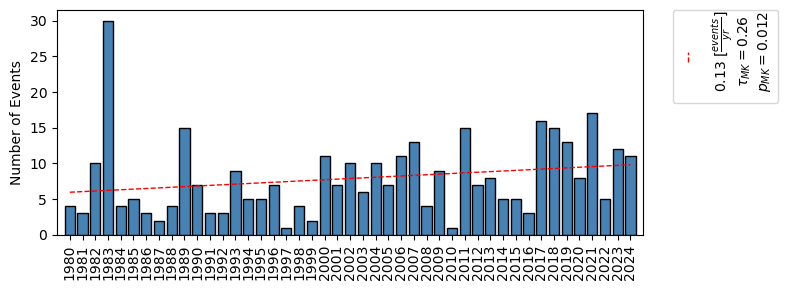

In [ ]:
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.transforms import Affine2D
from matplotlib.lines import Line2D
# Count events per year
years = times.year
counts = pd.Series(years).value_counts().sort_index()

# Numeric arrays for plotting/regression
x = counts.index.values.astype(float)   # years as numbers
y = counts.values.astype(float)         # counts

# OLS line (just for visualization)
slope, intercept, _, _, _ = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

# Mann–Kendall test (non-parametric trend)
mk_result = mk.original_test(y)  
tau = mk_result.Tau
pval = mk_result.p
mk_slope = mk_result.slope  # Sen's slope (events per year)
class VerticalLineHandler(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # draw a vertical line centered in the legend entry box
        x = xdescent + width * 0.5
        y0 = ydescent
        y1 = ydescent + height
        line = Line2D([x, x], [y0, y1],
                      linestyle=orig_handle.get_linestyle(),
                      linewidth=orig_handle.get_linewidth(),
                      color=orig_handle.get_color())
        line.set_transform(trans)  # legend transform
        return [line]


# Plot
fig, ax = plt.subplots(figsize=(8,3))

# Bars: events per year
ax.bar(x, y, width=0.8, color="steelblue", edgecolor="black")
label_str = (
    f"{mk_slope:.2f} " + r"$[\frac{events}{yr}]$" + "\n"
    + r"$\tau_{MK}=$" + f"{tau:.2f}" + "\n"
    + r"$p_{MK}=$" + f"{pval:.3f}"
)
# Trend line with MK results in legend
line,=ax.plot(
    x_fit, y_fit, color="red", linewidth=1,linestyle="--",
    label=label_str)

# Axes & legend

ax.set_ylabel("Number of Events")
ax.set_xlim(x.min()-1, x.max()+1)
plt.xticks(x, rotation=90)


# legend with vertical line + (optionally) rotate text 90°
ax.legend(
    loc="upper left", bbox_to_anchor=(1.05, 1),)

plt.tight_layout()

plt.savefig("/scratch/tmiesse/project/figures/events_per_year_with_MK_slope.png",
            dpi=300, bbox_inches="tight")
plt.show()

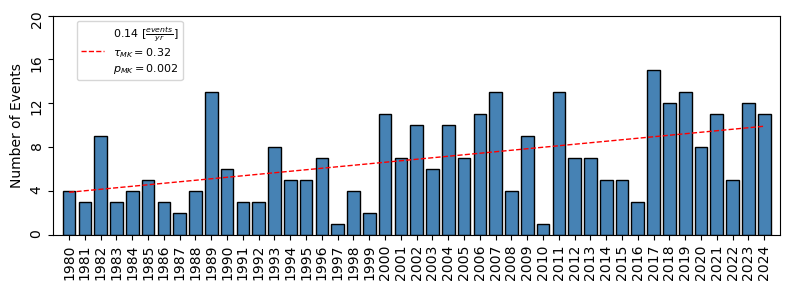

In [25]:
from matplotlib.legend_handler import HandlerLine2D
# ---- EXCLUDE events inside this bbox (core location) ----
lat1, lat2 = 66.0, 67.06
lon1, lon2 = -161.907, -159.875


# 
lon_ev = ds_events["core_lon" if "core_lon" in ds_events else "lon"].values
lat_ev = ds_events["core_lat" if "core_lat" in ds_events else "lat"].values
in_bbox  = (lat_ev >= lat1) & (lat_ev <= lat2) & (lon_ev >= lon1) & (lon_ev <= lon2)
keep     = ~in_bbox

# Filtered times (use these going forward)
times_f  = pd.to_datetime(times[keep])

# ---- Recompute histogram inputs on the FILTERED set ----
years = times_f.year
counts = pd.Series(years).value_counts().sort_index()

# Numeric arrays for plotting/regression
x = counts.index.values.astype(float)   # years as numbers
y = counts.values.astype(float)         # counts

# OLS line (visual reference)
slope, intercept, _, _, _ = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

# Mann–Kendall test (non-parametric trend)
mk_result = mk.original_test(y)
tau = mk_result.Tau
pval = mk_result.p
mk_slope = mk_result.slope  # Sen's slope (events per year)

# Optional: vertical-line handler (kept if you still want it later)
class VerticalLineHandler(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        x_mid = xdescent + 0.5 * width
        y0 = ydescent + 0.20 * height
        y1 = ydescent + 0.80 * height
        line = Line2D([x_mid, x_mid], [y0, y1],
                      linestyle=orig_handle.get_linestyle(),
                      linewidth=orig_handle.get_linewidth(),
                      color=orig_handle.get_color())
        line.set_transform(trans)
        return [line]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8,3))

# Bars: events per year (filtered)
ax.bar(x, y, width=0.8, color="steelblue", edgecolor="black")

# Trend line with MK stats in legend
label_str = (
    f"{mk_slope:.2f} " + r"$[\frac{events}{yr}]$" + "\n"
    + r"$\tau_{MK}=$" + f"{tau:.2f}" + "\n"
    + r"$p_{MK}=$" + f"{pval:.3f}"
)
line, = ax.plot(x_fit, y_fit, color="red", linewidth=1, linestyle="--", label=label_str)

# Axes & legend
yrange  = np.arange(0, 20.1, 4)
ax.set_ylabel("Number of Events")
ax.set_xlim(x.min()-1, x.max()+1)
ax.set_ylim([np.min(yrange), np.max(yrange)])
plt.xticks(x, rotation=90)
plt.yticks(yrange,rotation=90)
ax.legend(loc="upper left", bbox_to_anchor=(.025, 1),fontsize=8)
plt.tight_layout()

plt.savefig("/scratch/tmiesse/project/figures/events_per_year_with_MK_slope_bbox_excluded.png",
            dpi=300, bbox_inches="tight")
plt.show()

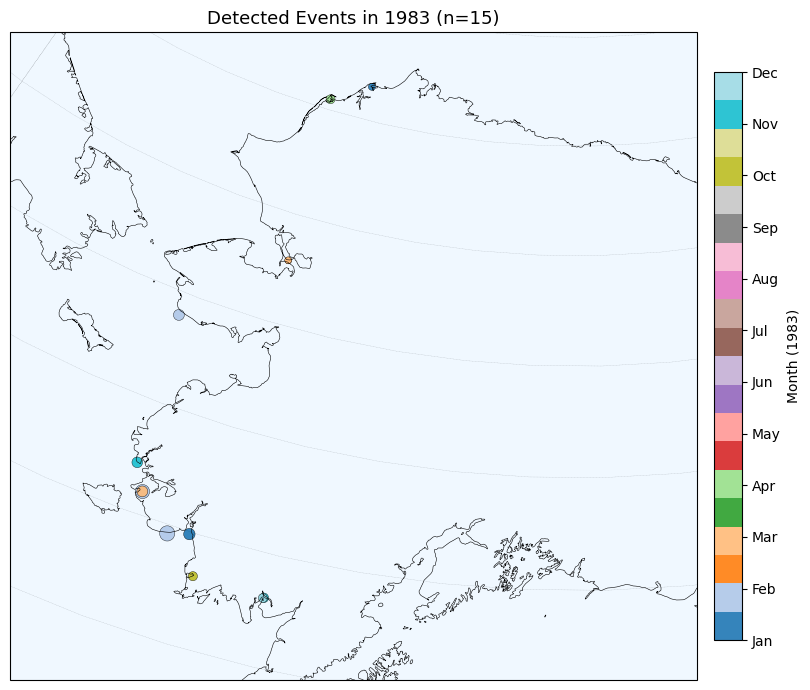

Saved: /scratch/tmiesse/project/figures/events_map_1983.png


In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig_path  = "/scratch/tmiesse/project/figures/events_map_1983.png"
extent    = [-169, -140, 58, 71]  # lon_min, lon_max, lat_min, lat_max (Alaska domain)
proj      = ccrs.NorthPolarStereo(central_longitude=-145)

lon_name = "core_lon" if "core_lon" in ds_events.variables else ("lon" if "lon" in ds_events.variables else None)
lat_name = "core_lat" if "core_lat" in ds_events.variables else ("lat" if "lat" in ds_events.variables else None)
if lon_name is None or lat_name is None:
    raise KeyError("Could not find lon/lat variables ('core_lon'/'core_lat' or 'lon'/'lat') in the events file.")

# Extract and filter to 1983
times = pd.to_datetime(ds_events["time"].values)
mask_1983 = (times.year == 1989)
if not mask_1983.any():
    print("No events found for 1983.")
else:
    lons   = ds_events[lon_name].values[mask_1983]
    lats   = ds_events[lat_name].values[mask_1983]
    months = times[mask_1983].month

    # Optional: area scaling if available
    if "area95_km2" in ds_events.variables:
        area = ds_events["area95_km2"].values[mask_1983].astype(float)
        # scale marker sizes (points^2) between ~20 and ~120 using clipped percentile
        scale_ref = np.nanpercentile(area, 95) if np.isfinite(area).any() else 1.0
        scale_ref = scale_ref if scale_ref > 0 else 1.0
        sizes = 20 + 100 * np.clip(area / scale_ref, 0, 1)
    else:
        sizes = np.full(lons.shape, 40.0)

    # --- Plot ---
    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=proj)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Base map
    ax.add_feature(cfeature.LAND,  facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
    ax.coastlines(resolution="10m", linewidth=0.4, color="black")

    # Gridlines (no labels)
    gl = ax.gridlines(draw_labels=False, linewidth=0.2, color="black", alpha=0.3, linestyle="--")
    # Scatter colored by month
    sc = ax.scatter(
        lons, lats,
        c=months, s=sizes, cmap="tab20", vmin=1, vmax=12,
        edgecolor="k", linewidths=0.3, alpha=0.9,
        transform=ccrs.PlateCarree()
    )

    # Colorbar for months
    cb = plt.colorbar(sc, ax=ax, orientation="vertical", fraction=0.035, pad=0.02)
    cb.set_label("Month (1983)")
    cb.set_ticks(np.arange(1,13,1))
    cb.set_ticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

    # Title with count
    n_events_1983 = np.count_nonzero(mask_1983)
    plt.title(f"Detected Events in 1983 (n={n_events_1983})", fontsize=13)

    plt.tight_layout()
    #plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")